In [1]:
using Pkg
Pkg.activate("C:/Users/av589/Desktop/Julia/ants")
using Plots
using DifferentialEquations
using LaTeXStrings
using NLsolve
using IntervalArithmetic, IntervalArithmetic.Symbols, IntervalRootFinding
using LinearAlgebra

  Activating project at `C:\Users\av589\Desktop\Julia\ants`


In [73]:
function model_3d_t(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n)=p
    S,C,T = x
    B = 1 - S - C - T
    Sdot = -(alphaC+alphaB+alphaT)*S + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n)
    Cdot = alphaC*S - omegaC*C/(1+ (C/k)^n)
    Tdot = alphaT*S - beta*T
    [
        Sdot
        Cdot
        Tdot
    ]
end

function model_6d_t(x,p,t)
    (alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT)=p
    #print("bug")
    S,C,T,xC,xB,xT = x
    B = 1 - S - C - T
    Sdot = -(alphaC*(1+xC)+alphaB*(1+xB)+alphaT*(1+xT))*S + beta*T + (omegaC*C+omegaB*B)/(1+ (C/k)^n)
    Cdot = alphaC*(1+xC)*S - omegaC*C/(1+ (C/k)^n)
    Tdot = alphaT*(1+xT)*S - beta*T
    xCdot = -xC + tanh(u*(aC*xC + aBC*xB + aTC*xT + bC*C))
    xBdot = -xB + tanh(u*(aB*xB + aCB*xC + aTB*xT + bB*C))
    xTdot = -xT + tanh(u*(aT*xT + aCT*xC + aBT*xB + bT*C))
    [
        Sdot
        Cdot
        Tdot
        xCdot
        xBdot
        xTdot
    ]
end

model_6d_t (generic function with 1 method)

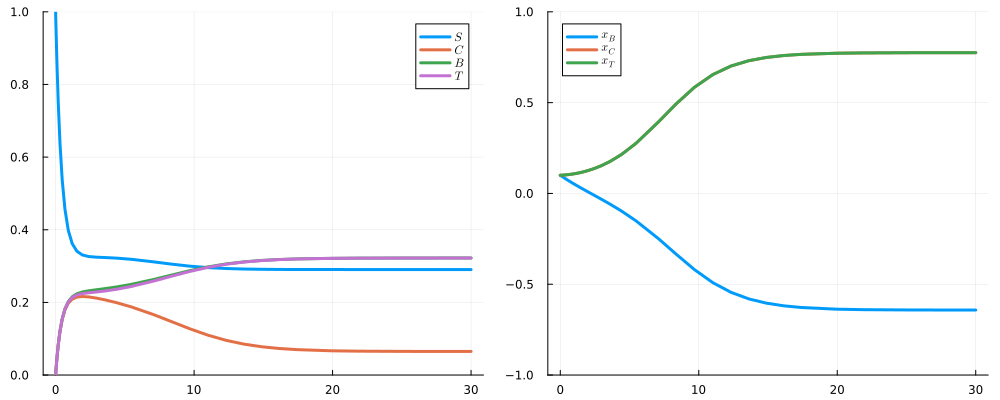

In [105]:
par = (alphaC=0.5, alphaB=0.5, alphaT=0.5, beta=0.8,omegaC=0.8,omegaB=0.8,k=0.5,n=4,u=0.8,aC=1.0,aB=1.0,aT=1.0,aBC=-0.2,aTC=-0.2,bC=-0.,aCB=-0.2,aTB=0.5,bB=-0.,aCT=-0.2,aBT=0.5,bT=0)
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n,u,aC,aB,aT,aBC,aTC,bC,aCB,aTB,bB,aCT,aBT,bT = par
u0 = [1.0,0,0,0.1,0.1,0.1]
tspan=(0.0,30.0)


prob_6d = ODEProblem(model_6d_t,u0,tspan,par)
sol6d = DifferentialEquations.solve(prob_6d)
S,C,T,xC,xB,xT = sol6d[1,:],sol6d[2,:],sol6d[3,:],sol6d[4,:],sol6d[5,:],sol6d[6,:]
B = 1 .- S .- C .- T

p1=plot(sol6d.t, [S,C,B,T], label = [L"S" L"C" L"B" L"T"],linewidth = 3, ylims = (0,1))
p2 = plot(sol6d.t, [xC,xB,xT], label = [L"x_B" L"x_C" L"x_T"], linewidth =3,ylims = (-1,1))

plot(p1,p2,size=(1000,400))

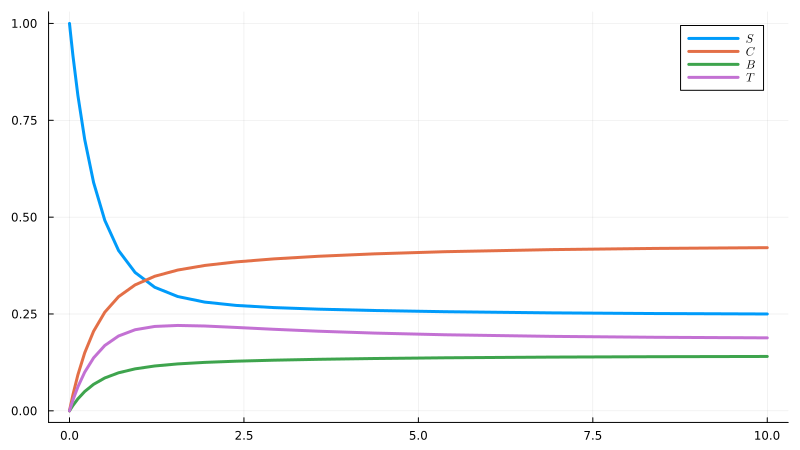

In [81]:
par = (alphaC=0.9,alphaB=0.3,alphaT=0.6,beta=0.8,omegaC=0.8,omegaB=0.8,k=0.5,n=4) # educated guesses for last 4
alphaC,alphaB,alphaT,beta,omegaC,omegaB,k,n = par
u0 = [1.0,0,0]
tspan=(0.0,10.0)
prob_3d = ODEProblem(model_3d_t,u0,tspan,par)
sol = DifferentialEquations.solve(prob_3d)
S,C,T = sol[1,:],sol[2,:],sol[3,:]
B = 1 .- S .- C .- T

plot(sol.t, [S,C,B,T], label = [L"S" L"C" L"B" L"T"],linewidth = 3, size = (800,450))